In [2]:
import mpmath as mp
import matplotlib.pyplot as plt

# =========================================================
# Arbitrary precision setup
# =========================================================

mp.mp.dps = 10   # decimal places; increase if needed

# =========================================================
# Utility helpers
# =========================================================

def mp_arange(start, stop, step):
    """
    Arbitrary-precision analogue of arange.
    Returns a Python list of mp.mpf values.
    """
    vals = []
    x = mp.mpf(start)
    stop = mp.mpf(stop)
    step = mp.mpf(step)

    # protect against accumulation issues
    while x < stop - step / 2:
        vals.append(x)
        x += step
    return vals


def to_float_list(x):
    """
    Convert list-like of mp numbers to Python floats for plotting.
    """
    return [float(v) for v in x]


def apply_plot_floor(y, floor=mp.mpf("1e-20"), mode="clip"):
    """
    Prepare positive data for semilogy plotting.

    mode = 'clip' : values below floor are set to floor
    mode = 'mask' : values below floor are set to None
    """
    out = []
    for v in y:
        if v < floor:
            if mode == "clip":
                out.append(floor)
            elif mode == "mask":
                out.append(None)
            else:
                raise ValueError("mode must be 'clip' or 'mask'")
        else:
            out.append(v)
    return out


# =========================================================
# Stable arbitrary-precision JLP Hamiltonian
# =========================================================

def hamiltonian_jlp_mpmath(ns: int, phi_max, omega):
    """
    Arbitrary-precision JLP Hamiltonian:
        H = 1/2 (Pi^2 + omega^2 phi^2)

    Uses a standard DFT matrix plus diagonal phases, all in mpmath.
    Returns:
        H, phi
    where
        H   : mp.matrix (ns x ns)
        phi : list of mp.mpf
    """
    phi_max = mp.mpf(phi_max)
    omega = mp.mpf(omega)

    n = [mp.mpf(i) for i in range(ns)]

    # Field grid
    delta_phi = 2 * phi_max / (ns - 1)
    phi = [-phi_max + i * delta_phi for i in n]

    # Momentum grid
    kmax = mp.pi / delta_phi
    delta_k = 2 * mp.pi / (delta_phi * ns)
    k = [-kmax + i * delta_k for i in n]

    # phi^2 diagonal
    phi2 = mp.zeros(ns)
    for i in range(ns):
        phi2[i, i] = phi[i] ** 2

    # Standard DFT matrix
    W = mp.zeros(ns, ns)
    sqrt_ns = mp.sqrt(ns)
    for m in range(ns):
        for nn in range(ns):
            W[m, nn] = mp.e ** (-2j * mp.pi * m * nn / ns) / sqrt_ns

    # Diagonal phase factors
    Dleft = mp.zeros(ns)
    Dright = mp.zeros(ns)
    for m in range(ns):
        Dleft[m, m] = mp.e ** (-1j * k[m] * (-phi_max))
    for nn in range(ns):
        Dright[nn, nn] = mp.e ** (-1j * (-kmax) * phi[nn])

    F = Dleft * W * Dright

    # diag(k^2)
    K2 = mp.zeros(ns)
    for i in range(ns):
        K2[i, i] = k[i] ** 2

    # Kinetic term in field basis
    pi_phi2 = F.conjugate().transpose() * K2 * F

    # Hamiltonian
    H = mp.mpf("0.5") * (pi_phi2 + omega**2 * phi2)

    # Enforce Hermiticity explicitly, then keep only the real part
    Hh = mp.zeros(ns, ns)
    for i in range(ns):
        for j in range(ns):
            Hh[i, j] = mp.re(mp.mpf("0.5") * (H[i, j] + mp.conj(H[j, i])))

    return Hh, phi


# =========================================================
# Arbitrary-precision FDC Hamiltonian
# =========================================================

def hamiltonian_fd_mpmath(ns: int, phi_max, omega):
    """
    Arbitrary-precision FDC Hamiltonian.
    Returns:
        H, phi
    """
    phi_max = mp.mpf(phi_max)
    omega = mp.mpf(omega)

    delta_phi = 2 * phi_max / (ns - 1)
    phi = [-phi_max + i * delta_phi for i in range(ns)]

    phi2 = mp.zeros(ns)
    for i in range(ns):
        phi2[i, i] = phi[i] ** 2

    lap = mp.zeros(ns, ns)
    for i in range(ns):
        lap[i, i] = mp.mpf("2.0")
        lap[i, (i + 1) % ns] = mp.mpf("-1.0")
        lap[(i - 1) % ns, i] = mp.mpf("-1.0")
    lap = lap / (delta_phi**2)

    Piphi2 = lap

    P4 = Piphi2 ** 4
    H = mp.mpf("0.5") * (omega**2 * phi2 + Piphi2) + (delta_phi**2 / 24) * P4

    # Symmetrise
    Hh = mp.zeros(ns, ns)
    for i in range(ns):
        for j in range(ns):
            Hh[i, j] = mp.re(mp.mpf("0.5") * (H[i, j] + H[j, i]))

    return Hh, phi


# =========================================================
# Eigenvalue solve + diagnostics
# =========================================================

def solve_low_spectrum(method: str, ns: int, phi_max, omega, nlevels: int = 5):
    """
    Returns:
        eiglow         : lowest nlevels eigenvalues
        rel_error_pct  : abs relative percent error
        signed_rel_pct : signed relative percent error
        abs_error      : absolute error
    """
    if method == "JLP":
        H, _ = hamiltonian_jlp_mpmath(ns, phi_max, omega)
    elif method == "FD":
        H, _ = hamiltonian_fd_mpmath(ns, phi_max, omega)
    else:
        raise ValueError("method must be 'JLP' or 'FD'")

    eigvals = mp.eigsy(H, eigvals_only=True)

    # eigsy may still return mpc objects with tiny imaginary parts
    eigvals = [mp.re(ev) for ev in eigvals]
    eigvals = sorted(eigvals)[:nlevels]

    omega = mp.mpf(omega)
    exact = [omega * (n + mp.mpf("0.5")) for n in range(nlevels)]

    signed_rel_pct = [((eigvals[i] - exact[i]) / exact[i]) * 100 for i in range(nlevels)]
    rel_error_pct = [abs(v) for v in signed_rel_pct]
    abs_error = [abs(eigvals[i] - exact[i]) for i in range(nlevels)]

    return eigvals, rel_error_pct, signed_rel_pct, abs_error


def compute_results(method: str, nq_list, phi_max_values, omega, nlevels: int = 5):
    """
    Returns nested dict:
      results[nq]['phi_max']
      results[nq]['eigvals']
      results[nq]['rel_error_pct']
      results[nq]['signed_rel_pct']
      results[nq]['abs_error']
    """
    results = {}

    for nq in nq_list:
        ns = 2**nq

        eigvals_all = []
        rel_all = []
        signed_all = []
        abs_all = []

        print(f"Running {method}, nQ={nq}, ns={ns} ...")

        for pm in phi_max_values:
            eigvals, relerr, signederr, abserr = solve_low_spectrum(
                method=method,
                ns=ns,
                phi_max=pm,
                omega=omega,
                nlevels=nlevels
            )
            eigvals_all.append(eigvals)
            rel_all.append(relerr)
            signed_all.append(signederr)
            abs_all.append(abserr)

        results[nq] = {
            "phi_max": phi_max_values,
            "eigvals": eigvals_all,
            "rel_error_pct": rel_all,
            "signed_rel_pct": signed_all,
            "abs_error": abs_all,
        }

    return results


def optimal_phi_max(nphi: int, omega=1):
    omega = mp.mpf(omega)
    nphi = mp.mpf(nphi)
    return (1 / mp.sqrt(omega)) * mp.sqrt((mp.pi / 2) * (((nphi - 1) ** 2) / nphi))


def print_minimum_diagnostics(results, nq: int, level: int = 0, label: str = ""):
    """
    Print diagnostic information around the minimum.
    """
    phi = results[nq]["phi_max"]
    rel = [row[level] for row in results[nq]["rel_error_pct"]]
    signed = [row[level] for row in results[nq]["signed_rel_pct"]]
    abs_err = [row[level] for row in results[nq]["abs_error"]]
    eigvals = [row[level] for row in results[nq]["eigvals"]]

    imin = min(range(len(rel)), key=lambda i: rel[i])

    print("=" * 78)
    print(f"{label} nQ={nq}, level={level}")
    print(f"Minimum at phi_max = {phi[imin]}")
    print(f"Minimum relative error (%) = {rel[imin]}")
    print(f"Signed relative error (%)  = {signed[imin]}")
    print(f"Absolute error             = {abs_err[imin]}")
    print(f"Numerical eigenvalue       = {eigvals[imin]}")
    print("-" * 78)

    i0 = max(0, imin - 5)
    i1 = min(len(phi), imin + 6)

    print(" index      phi_max                   rel_error(%)              signed_error(%)            abs_error")
    for i in range(i0, i1):
        print(f"{i:5d}   {str(phi[i]):>18}   {str(rel[i]):>24}   {str(signed[i]):>24}   {str(abs_err[i]):>24}")
    print("=" * 78)
    print()


# =========================================================
# User controls
# =========================================================

omega = mp.mpf("1.0")
nq_list = [3, 4, 5]
nlevels = 5

# Coarse scan
phi_max_values_coarse = mp_arange("0.01", "20", "0.05")

# Fine scan around the nQ=5 minimum
phi_max_values_fine = mp_arange("5.5", "8.5", "0.01")

# plotting floor in percent
plot_floor_pct = mp.mpf("1e-25")
plot_floor_mode = "clip"   # 'clip' or 'mask'

# =========================================================
# Compute
# =========================================================

results_jlp_coarse = compute_results("JLP", nq_list, phi_max_values_coarse, omega, nlevels=nlevels)
results_fd_coarse  = compute_results("FD",  nq_list, phi_max_values_coarse, omega, nlevels=nlevels)

#results_jlp_fine = compute_results("JLP", [5], phi_max_values_fine, omega, nlevels=nlevels)

# Diagnostics
for nq in nq_list:
    print_minimum_diagnostics(results_jlp_coarse, nq=nq, level=0, label="JLP coarse")
#print_minimum_diagnostics(results_jlp_fine, nq=5, level=0, label="JLP fine")

Running JLP, nQ=3, ns=8 ...
Running JLP, nQ=4, ns=16 ...
Running JLP, nQ=5, ns=32 ...
Running FD, nQ=3, ns=8 ...
Running FD, nQ=4, ns=16 ...
Running FD, nQ=5, ns=32 ...
JLP coarse nQ=3, level=0
Minimum at phi_max = 3.11
Minimum relative error (%) = 0.0004063775123
Signed relative error (%)  = -0.0004063775123
Absolute error             = 2.031887561e-6
Numerical eigenvalue       = 0.4999979681
------------------------------------------------------------------------------
 index      phi_max                   rel_error(%)              signed_error(%)            abs_error
   57                 2.86              0.01882549477             -0.01882549477             9.412747386e-5
   58                 2.91              0.01286436527             -0.01286436527             6.432182636e-5
   59                 2.96             0.008503315621            -0.008503315621             4.251657811e-5
   60                 3.01             0.005227354268            -0.005227354268             2.6136

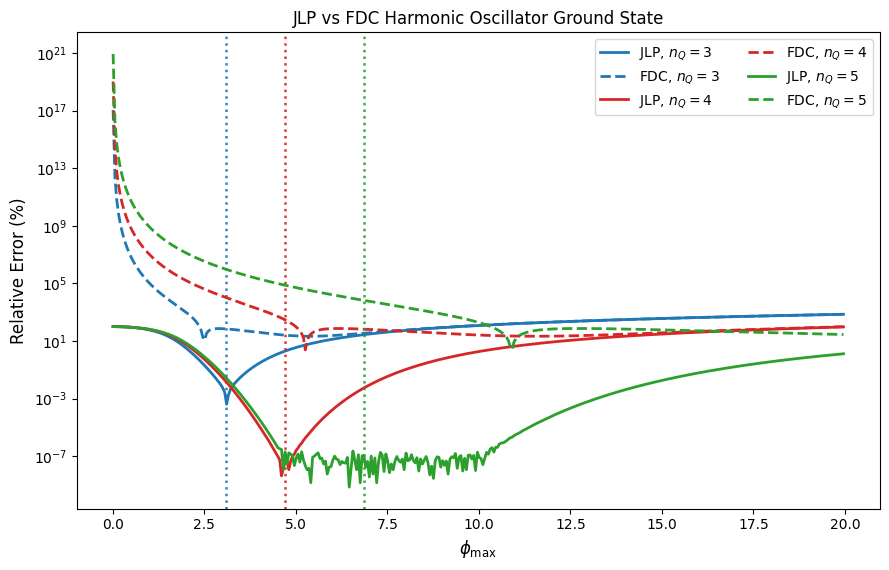

In [3]:
# =========================================================
# Plot 1: JLP vs FDC ground-state relative error
# =========================================================

colors = ["tab:blue", "tab:red", "tab:green"]
opt_list = [optimal_phi_max(2**nq, omega) for nq in nq_list]

fig = plt.figure(figsize=(9, 5.8))

for c, nq, opt_pm in zip(colors, nq_list, opt_list):
    x_jlp = results_jlp_coarse[nq]["phi_max"]
    y_jlp = [row[0] for row in results_jlp_coarse[nq]["rel_error_pct"]]
    y_jlp = apply_plot_floor(y_jlp, floor=plot_floor_pct, mode=plot_floor_mode)

    x_fd = results_fd_coarse[nq]["phi_max"]
    y_fd = [row[0] for row in results_fd_coarse[nq]["rel_error_pct"]]
    y_fd = apply_plot_floor(y_fd, floor=plot_floor_pct, mode=plot_floor_mode)

    plt.semilogy(
        to_float_list(x_jlp),
        [float(v) if v is not None else None for v in y_jlp],
        color=c, linewidth=2, linestyle="-", label=fr"JLP, $n_Q={nq}$"
    )

    plt.semilogy(
        to_float_list(x_fd),
        [float(v) if v is not None else None for v in y_fd],
        color=c, linewidth=2, linestyle="--", label=fr"FDC, $n_Q={nq}$"
    )

    plt.axvline(float(opt_pm), color=c, linestyle=":", linewidth=1.8, alpha=0.9)

plt.xlabel(r"$\phi_{\max}$", fontsize=12)
plt.ylabel(r"Relative Error (%)", fontsize=12)
plt.title("JLP vs FDC Harmonic Oscillator Ground State", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()

fig.savefig(
    "JLP_vs_FDC_ground_state.png",  # PDF is best for papers
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
Full copy-paste script: JLP + HO + combined comparison plot
with optional arbitrary precision via mpmath.

Set:
    USE_MP = False   -> NumPy / SciPy mode
    USE_MP = True    -> mpmath arbitrary-precision mode
"""

fontsize = 12

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.linalg import eigh  # Hermitian eigensolver
except Exception:
    eigh = None

try:
    import mpmath as mp
except Exception:
    mp = None


# =========================================================
# USER CONTROLS
# =========================================================
USE_MP = True          # False = NumPy mode, True = arbitrary precision mode
MP_DPS = 30            # decimal places when USE_MP=True


# =========================================================
# Utilities
# =========================================================
def hermitise(H: np.ndarray) -> np.ndarray:
    return 0.5 * (H + H.conj().T)


def ground_state_energy(H: np.ndarray) -> float:
    """Smallest eigenvalue of Hermitian H (NumPy mode)."""
    if eigh is not None:
        w = eigh(H, eigvals_only=True)
        return float(np.real(w[0]))
    w = np.linalg.eigvalsh(H)
    return float(np.real(w[0]))


def clamp_nonpositive_to_min_positive(y):
    """
    Replace all y <= 0 with the smallest strictly-positive value in y.
    Works for both float arrays and Python/mpmath lists.
    """
    y_list = list(y)
    pos = [v for v in y_list if v > 0]
    if len(pos) == 0:
        raise ValueError("No strictly-positive values found; cannot clamp y<=0.")
    min_pos = min(pos)
    return [min_pos if v <= 0 else v for v in y_list]


def to_float_list(x):
    """Convert iterable to plain Python floats for plotting."""
    return [float(v) for v in x]


def mp_linspace_from_arange(start, stop, step):
    """
    mpmath equivalent of np.arange(start, stop_inclusive, step),
    with inclusive upper bound behaviour similar to your script.
    """
    vals = []
    x = mp.mpf(str(start))
    stop = mp.mpf(str(stop))
    step = mp.mpf(str(step))
    half = step / 2
    while x <= stop + half:
        vals.append(x)
        x += step
    return vals


# =========================================================
# NumPy JLP Hamiltonian
# =========================================================
def hamiltonian_jlp_np(ns: int, phi_max: float, lam: float):
    if ns < 2:
        raise ValueError("ns must be >= 2")

    delta_phi = 2.0 * phi_max / (ns - 1)
    beta = np.arange(ns, dtype=float)
    phi = -phi_max + beta * delta_phi
    phi2 = np.diag(phi**2)

    kmax = np.pi / delta_phi
    delta_k = 2.0 * np.pi / (delta_phi * ns)
    betak = np.arange(ns, dtype=float)
    k = -kmax + betak * delta_k

    F = np.exp(-1j * np.outer(k, phi)) / np.sqrt(ns)
    Pik2 = np.diag(k**2)
    Piphi2 = F.conj().T @ Pik2 @ F

    H = 0.5 * (phi2 + Piphi2) + (lam / 24.0) * np.linalg.matrix_power(phi2, 2)
    H = hermitise(H)
    return H, phi


def precision_e0_jlp_np(ns: int, phi_max: float, lam: float, e0_ref: float) -> float:
    H, _ = hamiltonian_jlp_np(ns, phi_max, lam)
    e0 = ground_state_energy(H)
    return 100.0 * abs((e0 - e0_ref) / e0_ref)


# =========================================================
# NumPy HO Hamiltonian
# =========================================================
def ladder_ops_np(ns: int):
    a = np.zeros((ns, ns), dtype=complex)
    for m in range(ns - 1):
        a[m, m + 1] = np.sqrt(m + 1.0)
    ad = a.conj().T
    return a, ad


def hamiltonian_ho_np(ns: int, omega: float, lam: float):
    a, ad = ladder_ops_np(ns)
    phi = (a + ad) / np.sqrt(2.0 * omega)
    pi = 1j * np.sqrt(omega / 2.0) * (ad - a)
    H = 0.5 * (pi @ pi + phi @ phi) + (lam / 24.0) * np.linalg.matrix_power(phi, 4)
    return hermitise(H)


def precision_e0_ho_np(ns: int, omega: float, lam: float, e0_ref: float) -> float:
    H = hamiltonian_ho_np(ns, omega, lam)
    e0 = ground_state_energy(H)
    return 100.0 * abs((e0 - e0_ref) / e0_ref)


# =========================================================
# mpmath JLP Hamiltonian
# =========================================================
def hamiltonian_jlp_mp(ns: int, phi_max, lam):
    if mp is None:
        raise ImportError("mpmath is not installed.")

    phi_max = mp.mpf(phi_max)
    lam = mp.mpf(lam)

    delta_phi = 2 * phi_max / (ns - 1)
    phi = [-phi_max + i * delta_phi for i in range(ns)]

    phi2 = mp.zeros(ns)
    for i in range(ns):
        phi2[i, i] = phi[i] ** 2

    kmax = mp.pi / delta_phi
    delta_k = 2 * mp.pi / (delta_phi * ns)
    k = [-kmax + i * delta_k for i in range(ns)]

    F = mp.zeros(ns, ns)
    root_ns = mp.sqrt(ns)
    for i in range(ns):
        for j in range(ns):
            F[i, j] = mp.e ** (-1j * k[i] * phi[j]) / root_ns

    Pik2 = mp.zeros(ns)
    for i in range(ns):
        Pik2[i, i] = k[i] ** 2

    Piphi2 = F.conjugate().transpose() * Pik2 * F

    # phi2^2 is diagonal since phi2 is diagonal
    phi4 = mp.zeros(ns)
    for i in range(ns):
        phi4[i, i] = phi2[i, i] ** 2

    H = mp.mpf("0.5") * (phi2 + Piphi2) + (lam / 24) * phi4

    # force explicitly Hermitian and real-valued
    Hh = mp.zeros(ns, ns)
    for i in range(ns):
        for j in range(ns):
            Hh[i, j] = mp.re((H[i, j] + mp.conj(H[j, i])) / 2)

    return Hh, phi


def ground_state_energy_mp(H):
    """Smallest eigenvalue of Hermitian H (mpmath mode)."""
    eigvals = mp.eigsy(H, eigvals_only=True)
    eigvals = [mp.re(ev) for ev in eigvals]
    eigvals = sorted(eigvals)
    return eigvals[0]


def precision_e0_jlp_mp(ns: int, phi_max, lam, e0_ref):
    H, _ = hamiltonian_jlp_mp(ns, phi_max, lam)
    e0 = ground_state_energy_mp(H)
    return mp.mpf("100") * abs((e0 - e0_ref) / e0_ref)


# =========================================================
# mpmath HO Hamiltonian
# =========================================================
def ladder_ops_mp(ns: int):
    if mp is None:
        raise ImportError("mpmath is not installed.")

    a = mp.zeros(ns, ns)
    for m in range(ns - 1):
        a[m, m + 1] = mp.sqrt(m + 1)
    ad = a.transpose()  # real matrix, so transpose = conjugate transpose here
    return a, ad


def matmul_mp(A, B):
    return A * B


def hamiltonian_ho_mp(ns: int, omega, lam):
    omega = mp.mpf(omega)
    lam = mp.mpf(lam)

    a, ad = ladder_ops_mp(ns)

    phi = (a + ad) / mp.sqrt(2 * omega)
    pi = 1j * mp.sqrt(omega / 2) * (ad - a)

    phi2 = phi * phi
    pi2 = pi * pi
    phi4 = phi2 * phi2

    H = mp.mpf("0.5") * (pi2 + phi2) + (lam / 24) * phi4

    Hh = mp.zeros(ns, ns)
    for i in range(ns):
        for j in range(ns):
            Hh[i, j] = mp.re((H[i, j] + mp.conj(H[j, i])) / 2)

    return Hh


def precision_e0_ho_mp(ns: int, omega, lam, e0_ref):
    H = hamiltonian_ho_mp(ns, omega, lam)
    e0 = ground_state_energy_mp(H)
    return mp.mpf("100") * abs((e0 - e0_ref) / e0_ref)


# =========================================================
# Unified compute wrappers
# =========================================================
def compute_results_jlp(nq_list, phi_max_values, lam, e0_ref):
    results = {}
    print(f"Computing JLP results for lambda = {lam}")
    print(f"Reference E0 = {e0_ref}")

    for nq in nq_list:
        nq = int(nq)
        ns = 2**nq
        print(f"→ Calculating for nQ = {nq} (ns = {ns})")
        rows = []
        for pm in phi_max_values:
            if USE_MP:
                err = precision_e0_jlp_mp(ns, pm, lam, e0_ref)
                rows.append([pm, err])
            else:
                err = precision_e0_jlp_np(ns, float(pm), float(lam), float(e0_ref))
                rows.append([float(pm), err])
        results[nq] = rows
    return results


def compute_results_ho(nq_list, omega_list, lam, e0_ref):
    results = {}
    print(f"Computing HO results for lambda = {lam}")
    print(f"Reference E0 = {e0_ref}")

    for nq in nq_list:
        nq = int(nq)
        ns = 2**nq
        print(f"→ Calculating for nQ = {nq} (ns = {ns})")
        rows = []
        for w in omega_list:
            if USE_MP:
                err = precision_e0_ho_mp(ns, w, lam, e0_ref)
                rows.append([w, err])
            else:
                err = precision_e0_ho_np(ns, float(w), float(lam), float(e0_ref))
                rows.append([float(w), err])
        results[nq] = rows
    return results


# =========================================================
# Plotting
# =========================================================
def plot_single_set_results_jlp(results, nq_list, lam, title_name="resultsJLP"):
    nq_list = [int(x) for x in nq_list]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(nq_list)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for c, nq in zip(colors, nq_list):
        data = results[nq]
        x = [row[0] for row in data]
        y = clamp_nonpositive_to_min_positive([row[1] for row in data])
        ax.plot(to_float_list(x), to_float_list(y), linestyle="--", linewidth=2, color=c, label=f"nQ = {nq}")

    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.set_xlabel("phiMax")
    ax.set_ylabel("Precision (%)")
    ax.set_title(f"{title_name}  λ = {lam} (Ground State Precision)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(nq_list), frameon=False)
    fig.tight_layout()
    return fig, ax


def plot_single_set_results_ho(results_ho, nq_list, lam, scalar=1.4, title_name="resultsHO"):
    nq_list = [int(x) for x in nq_list]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(nq_list)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for c, nq in zip(colors, nq_list):
        data = results_ho[nq]
        omega = [row[0] for row in data]
        omega_safe = [max(w, mp.mpf("1e-300")) if USE_MP else max(float(w), np.finfo(float).tiny) for w in omega]

        if USE_MP:
            xeff = [mp.mpf(str(scalar)) * mp.sqrt((2**nq) / w) for w in omega_safe]
        else:
            xeff = [scalar * np.sqrt((2.0**nq) / w) for w in omega_safe]

        y = clamp_nonpositive_to_min_positive([row[1] for row in data])
        ax.plot(to_float_list(xeff), to_float_list(y), linestyle="-", linewidth=2, color=c, label=f"nQ = {nq}")

    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.set_xlabel(f"effective phiMax = {scalar} * sqrt(2^nQ / ω)")
    ax.set_ylabel("Precision (%)")
    ax.set_title(f"{title_name}  λ = {lam} (HO basis)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(nq_list), frameon=False)
    fig.tight_layout()
    return fig, ax


# =========================================================
# Driver
# =========================================================

if USE_MP:
    if mp is None:
        raise ImportError("USE_MP=True but mpmath is not installed.")
    mp.mp.dps = MP_DPS
    print(f"Running in arbitrary-precision mode with mp.dps = {mp.mp.dps}")

    lam = mp.mpf("32.0")
    nq_list = [3, 4, 5]
    e0_ref = mp.mpf("0.8597426904455090")

    phi_max_values = mp_linspace_from_arange("0.5", "10.0", "0.05")
    omega_list = mp_linspace_from_arange("1.0", "50.0", "0.05")
else:
    print("Running in NumPy mode")

    lam = 32.0
    nq_list = [3, 4, 5]
    e0_ref = 0.8597426904455090

    phi_max_values = np.arange(0.5, 10.0 + 1e-12, 0.05)
    omega_list = np.arange(1.0, 50.0 + 1e-12, 0.05)

results_jlp = compute_results_jlp(nq_list, phi_max_values, lam, e0_ref)
results_ho = compute_results_ho(nq_list, omega_list, lam, e0_ref)

Running in arbitrary-precision mode with mp.dps = 30
Computing JLP results for lambda = 32.0
Reference E0 = 0.859742690445509
→ Calculating for nQ = 3 (ns = 8)
→ Calculating for nQ = 4 (ns = 16)
→ Calculating for nQ = 5 (ns = 32)
Computing HO results for lambda = 32.0
Reference E0 = 0.859742690445509
→ Calculating for nQ = 3 (ns = 8)
→ Calculating for nQ = 4 (ns = 16)
→ Calculating for nQ = 5 (ns = 32)


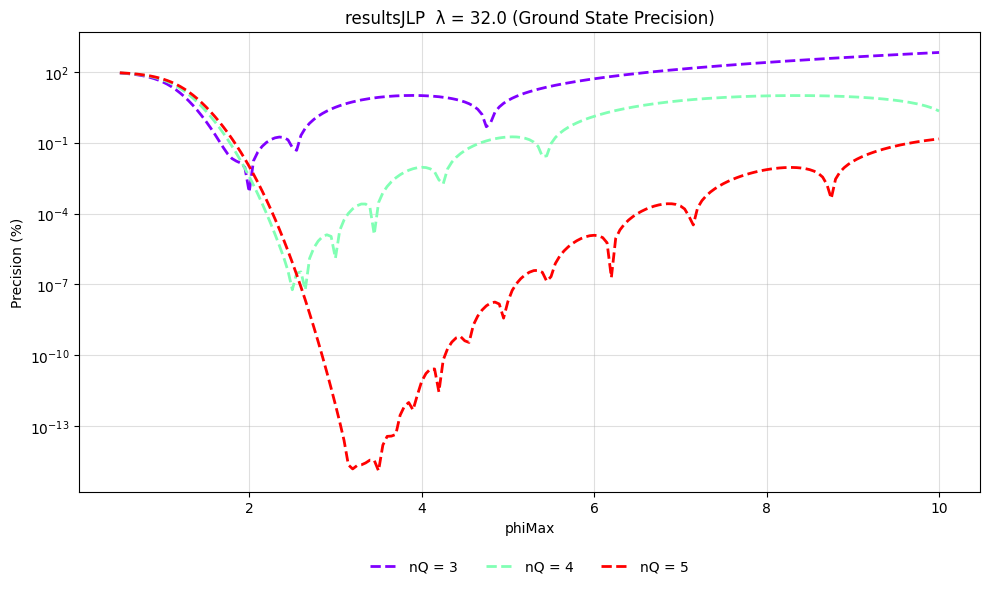

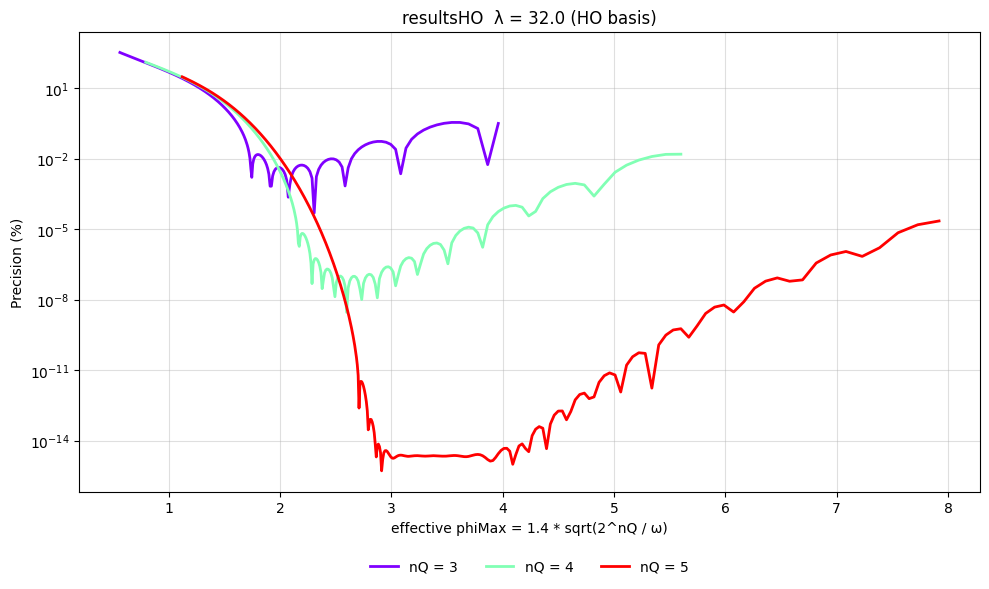

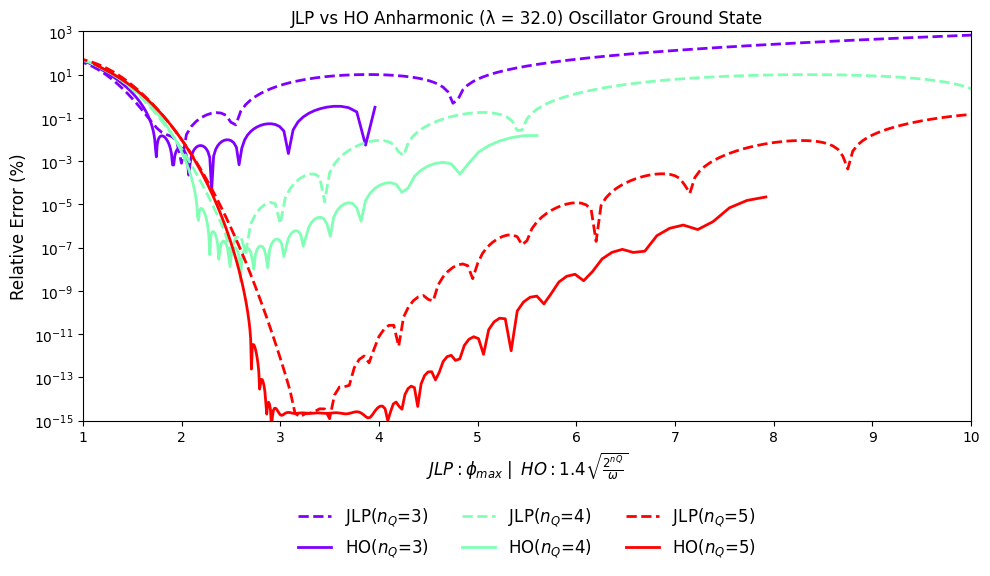

In [13]:
def compare_results_simple(results_jlp,
                           results_ho,
                           nq_list,
                           lam,
                           scalar=1.4,
                           xlim=(1.0, 10.0),
                           ylim=(1e-15, 1e3),
                           save_path=None,
                           clamp_results = True):
    nq_list = [int(x) for x in nq_list]
    colors = plt.cm.rainbow(np.linspace(0, 1, len(nq_list)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for c, nq in zip(colors, nq_list):
        dj = results_jlp[nq]
        xj = [row[0] for row in dj]
        if clamp_results == True:
            yj = clamp_nonpositive_to_min_positive([row[1] for row in dj])
        else:
            yj = [row[1] for row in dj]
        ax.plot(to_float_list(xj), to_float_list(yj), linestyle="--", linewidth=2, color=c, label=f"JLP" + r"($n_Q$" + f"={nq})")

        dh = results_ho[nq]
        omega = [row[0] for row in dh]
        omega_safe = [max(w, mp.mpf("1e-300")) if USE_MP else max(float(w), np.finfo(float).tiny) for w in omega]

        if USE_MP:
            xh = [mp.mpf(str(scalar)) * mp.sqrt((2**nq) / w) for w in omega_safe]
        else:
            xh = [scalar * np.sqrt((2.0**nq) / w) for w in omega_safe]

        if clamp_results == True:
            yh = clamp_nonpositive_to_min_positive([row[1] for row in dh])
        else:
            yh = [row[1] for row in dh]
        ax.plot(to_float_list(xh), to_float_list(yh), linestyle="-", linewidth=2, color=c, label=f"HO" + r"($n_Q$" + f"={nq})")

    ax.set_yscale("log")
    ax.set_xlabel(r"$JLP: \phi_{max}  \;|\;\; HO: 1.4 \sqrt{\frac{2^{nQ}}{\omega}}$", fontsize=12)
    ax.set_ylabel("Relative Error (%)", fontsize=12)
    ax.set_title(f"JLP vs HO Anharmonic (λ = {lam}) Oscillator Ground State", fontsize=12)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=12)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


plot_single_set_results_jlp(results_jlp, nq_list, lam)
plot_single_set_results_ho(results_ho, nq_list, lam, scalar=1.4)


compare_results_simple(
    results_jlp,
    results_ho,
    nq_list,
    lam,
    scalar=1.4,
    save_path="JLP_vs_HO_comparison.pdf",
    clamp_results = False
)

plt.show()